**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 6**
Ingeniería de características (FE)

---

*   NOMBRE: Ranulfo Jesús Rodríguez Alcántara
*   MATRÍCULA: A01194903

En esta actividad trabajarás con el archivo `computer_prices.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de computadoras portátiles y de escritorio, disponible en Kaggle.

Los datos fueron recopilados para analizar el rendimiento y el precio de los dispositivos, e incluyen información sobre hardware, almacenamiento, conectividad y otras especificaciones técnicas. Los indicadores incluidos son:

* `device_type`: Tipo de dispositivo (ej. laptop, desktop)
* `brand`: Marca del dispositivo
* `model`: Modelo del dispositivo
* `release_year`: Año de lanzamiento del dispositivo
* `os`: Sistema operativo instalado
* `form_factor`: Factor de forma o diseño del dispositivo (ej. laptop, ultrabook, desktop tower)
* `cpu_brand`: Marca del procesador
* `cpu_tier`: Nivel o gama del procesador, ordinal del 1 al 6 según desempeño
* `cpu_cores`: Número de núcleos del procesador
* `cpu_threads`: Número de hilos de ejecución del procesador
* `gpu_brand`: Marca de la tarjeta gráfica
* `gpu_model`: Modelo específico de la tarjeta gráfica
* `gpu_tier`: Nivel o gama de la GPU, ordinal del 1 al 6 según desempeño
* `vram_gb`: Memoria de video de la GPU en gigabytes
* `ram_gb`: Memoria RAM del dispositivo en gigabytes
* `storage_type`: Tipo de almacenamiento (ej. HDD, SSD)
* `storage_gb`: Capacidad de almacenamiento en gigabytes
* `storage_drive_count`: Número de unidades de almacenamiento instaladas
* `display_type`: Tipo de pantalla (ej. IPS, TN, OLED)
* `charger_watts`: Potencia del cargador (en watts) para laptops
* `psu_watts`: Potencia de la fuente de poder (en watts) para desktops
* `wifi`: Estándar de conectividad Wi-Fi (ej. Wi-Fi 5, 6, 6E, 7)
* `bluetooth`: Versión de Bluetooth
* `weight_kg`: Peso del dispositivo en kilogramos
* `warranty_months`: Meses de garantía del dispositivo
* `price`: Precio del dispositivo. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Instalar las bibliotecas necesarias
!pip install category_encoders

In [2]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from scipy.stats import probplot
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders.binary import BinaryEncoder

---

1. Descarga el archivo: `computer_prices.csv` y guarda, en un dataframe (`compu_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.
* Elimina las variables:
  * `model`: Debido a su altísima cardinalidad, lo que dificulta su uso en análisis y modelado.
  * `cpu_model`: Además de su elevada cardinalidad, su información ya está representada de manera implícita en otras variables como: `cpu_tier`, `cpu_cores` y `cpu_threads`

In [3]:
# ── Task 1.1  Cargar el CSV ──────────────────────────────────────────────────
compu_df = pd.read_csv("computer_prices.csv")

print(f"Shape: {compu_df.shape}")
compu_df.info()



Shape: (100000, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  gpu_brand            100000 non-null  object 
 12  gpu_model            100000 non-null  object 
 13  gpu_tier             100000 non-null  int64  
 14  vram_gb              100000 non-null  int64  
 15

In [4]:
# ── Task 1.2  Valores únicos por columna ────────────────────────────────────
unique_counts = compu_df.nunique().sort_values(ascending=False)
print(unique_counts.to_string())

model                  99036
cpu_model              26971
price                   3366
gpu_model                 49
weight_kg                 47
cpu_threads               25
ram_gb                    15
cpu_cores                 12
brand                     10
form_factor               10
psu_watts                  9
release_year               8
vram_gb                    8
charger_watts              7
cpu_tier                   6
display_type               6
gpu_tier                   6
storage_gb                 5
bluetooth                  5
storage_drive_count        4
storage_type               4
os                         4
gpu_brand                  4
wifi                       4
warranty_months            4
cpu_brand                  3
device_type                2


In [5]:
# ── Task 1.3  Eliminar columnas de alta cardinalidad ────────────────────────
compu_df.drop(columns=["model", "cpu_model"], inplace=True)

print(f"Shape resultante: {compu_df.shape}")
compu_df.info()

Shape resultante: (100000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   release_year         100000 non-null  int64  
 3   os                   100000 non-null  object 
 4   form_factor          100000 non-null  object 
 5   cpu_brand            100000 non-null  object 
 6   cpu_tier             100000 non-null  int64  
 7   cpu_cores            100000 non-null  int64  
 8   cpu_threads          100000 non-null  int64  
 9   gpu_brand            100000 non-null  object 
 10  gpu_model            100000 non-null  object 
 11  gpu_tier             100000 non-null  int64  
 12  vram_gb              100000 non-null  int64  
 13  ram_gb               100000 non-null  int64  
 14  storage_type         100000 non-null  

## Respuestas Task 1

### ¿Cuántas columnas son numéricas y cuántas de texto?

El dataframe original contiene **27 columnas** y **100,000 registros**.

| Tipo               | Conteo | Columnas |
|--------------------|--------|----------|
| Numéricas (`int64` / `float64`) | **15** | `release_year`, `cpu_tier`, `cpu_cores`, `cpu_threads`, `gpu_tier`, `vram_gb`, `ram_gb`, `storage_gb`, `storage_drive_count`, `charger_watts`, `psu_watts`, `bluetooth`, `weight_kg`, `warranty_months`, `price` |
| Texto (`str` / `object`)        | **12** | `device_type`, `brand`, `model`, `os`, `form_factor`, `cpu_brand`, `cpu_model`, `gpu_brand`, `gpu_model`, `storage_type`, `display_type`, `wifi` |

### Valores únicos destacados

| Columna       | Únicos  | Observación |
|---------------|---------|-------------|
| `model`       | 99,036  | Cardinalidad casi única por fila |
| `cpu_model`   | 26,971  | Cardinalidad muy alta |
| `gpu_model`   | 49      | Alta pero manejable con BinaryEncoder |
| `device_type` | 2       | Binaria: Desktop / Laptop |

### Justificación de las eliminaciones

| Columna     | Razón |
|-------------|-------|
| `model`     | Con 99,036 valores únicos en 100,000 filas, es prácticamente un identificador. No generaliza, no aporta señal estadística útil para predecir `price` y haría inviable cualquier codificación. |
| `cpu_model` | Con 26,971 valores únicos, presenta el mismo problema de cardinalidad extrema. Además, su información está representada de forma más compacta y ordenada en `cpu_tier` (ordinal 1–6), `cpu_cores` y `cpu_threads`, que capturan la capacidad del procesador sin la explosión dimensional. |

Tras la eliminación, el dataframe queda con **25 columnas**.

---

2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados y/o faltantes.
* Obtén las estadísticas descriptivas, separado las numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Genera histogramas para las numéricas y diagramas de barras para las categóricas. Con alta cardinalidad, sólo incluye los 10 valores más frecuentes.

In [6]:
# ── Task 2.1  Verificar duplicados y valores faltantes ──────────────────────
print("=" * 50)
print("VALORES DUPLICADOS")
print("=" * 50)
n_dup = compu_df.duplicated().sum()
print(f"Filas duplicadas: {n_dup}")

print("\n" + "=" * 50)
print("VALORES FALTANTES")
print("=" * 50)
missing = compu_df.isnull().sum()
missing_pct = (missing / len(compu_df) * 100).round(2)
missing_df = pd.DataFrame({"Faltantes": missing, "Porcentaje (%)": missing_pct})
missing_df = missing_df[missing_df["Faltantes"] > 0]

if missing_df.empty:
    print("✓ No se encontraron valores faltantes en ninguna columna.")
else:
    print(missing_df)

VALORES DUPLICADOS
Filas duplicadas: 0

VALORES FALTANTES
✓ No se encontraron valores faltantes en ninguna columna.


In [7]:
# ── Task 2.2a  Estadísticas descriptivas — variables numéricas ──────────────
num_cols = compu_df.select_dtypes(include='number').columns.tolist()

print(f"Variables numéricas ({len(num_cols)}): {num_cols}\n")
compu_df[num_cols].describe().T.round(2)

Variables numéricas (15): ['release_year', 'cpu_tier', 'cpu_cores', 'cpu_threads', 'gpu_tier', 'vram_gb', 'ram_gb', 'storage_gb', 'storage_drive_count', 'charger_watts', 'psu_watts', 'bluetooth', 'weight_kg', 'warranty_months', 'price']



,count,mean,std,min,25%,50%,75%,max
release_year,100000.0,2022.32,2.03,2018.00,2021.00,2023.00,2024.00,2025.00
cpu_tier,100000.0,3.15,1.37,1.00,2.00,3.00,4.00,6.00
cpu_cores,100000.0,10.52,5.04,4.00,6.00,8.00,14.00,28.00
cpu_threads,100000.0,19.37,9.72,4.00,12.00,16.00,24.00,56.00
gpu_tier,100000.0,2.99,1.46,1.00,2.00,3.00,4.00,6.00
vram_gb,100000.0,6.15,3.96,0.00,4.00,6.00,8.00,16.00
ram_gb,100000.0,39.71,31.90,8.00,16.00,32.00,64.00,144.00
storage_gb,100000.0,903.94,774.24,256.00,512.00,512.00,1024.00,4096.00
storage_drive_count,100000.0,1.52,0.80,1.00,1.00,1.00,2.00,4.00
charger_watts,100000.0,61.38,62.80,0.00,0.00,65.00,90.00,240.00


In [8]:
# ── Task 2.2b  Estadísticas descriptivas — variables categóricas ─────────────
cat_cols = compu_df.select_dtypes(include='object').columns.tolist()

print(f"Variables categóricas ({len(cat_cols)}): {cat_cols}\n")
print(compu_df[cat_cols].describe())

print("\n" + "=" * 60)
print("TABLAS DE FRECUENCIA")
print("=" * 60)

for col in cat_cols:
    vc = compu_df[col].value_counts()
    vc_pct = (vc / len(compu_df) * 100).round(2)
    freq_df = pd.DataFrame({"Frecuencia": vc, "Porcentaje (%)": vc_pct})
    print(f"\n── {col} ({compu_df[col].nunique()} categorías) ──")
    print(freq_df.to_string())

Variables categóricas (10): ['device_type', 'brand', 'os', 'form_factor', 'cpu_brand', 'gpu_brand', 'gpu_model', 'storage_type', 'display_type', 'wifi']

       device_type   brand       os form_factor cpu_brand gpu_brand  \
count       100000  100000   100000      100000    100000    100000   
unique           2      10        4          10         3         4   
top         Laptop  Lenovo  Windows  Mainstream     Intel    NVIDIA   
freq         59844   15992    71817       17819     52774     54712   

               gpu_model storage_type display_type     wifi  
count             100000       100000       100000   100000  
unique                49            4            6        4  
top     Apple Integrated         NVMe          LED  Wi-Fi 6  
freq               18922        45059        32000    46149  

TABLAS DE FRECUENCIA

── device_type (2 categorías) ──
             Frecuencia  Porcentaje (%)
device_type                            
Laptop            59844           59.84
Desk

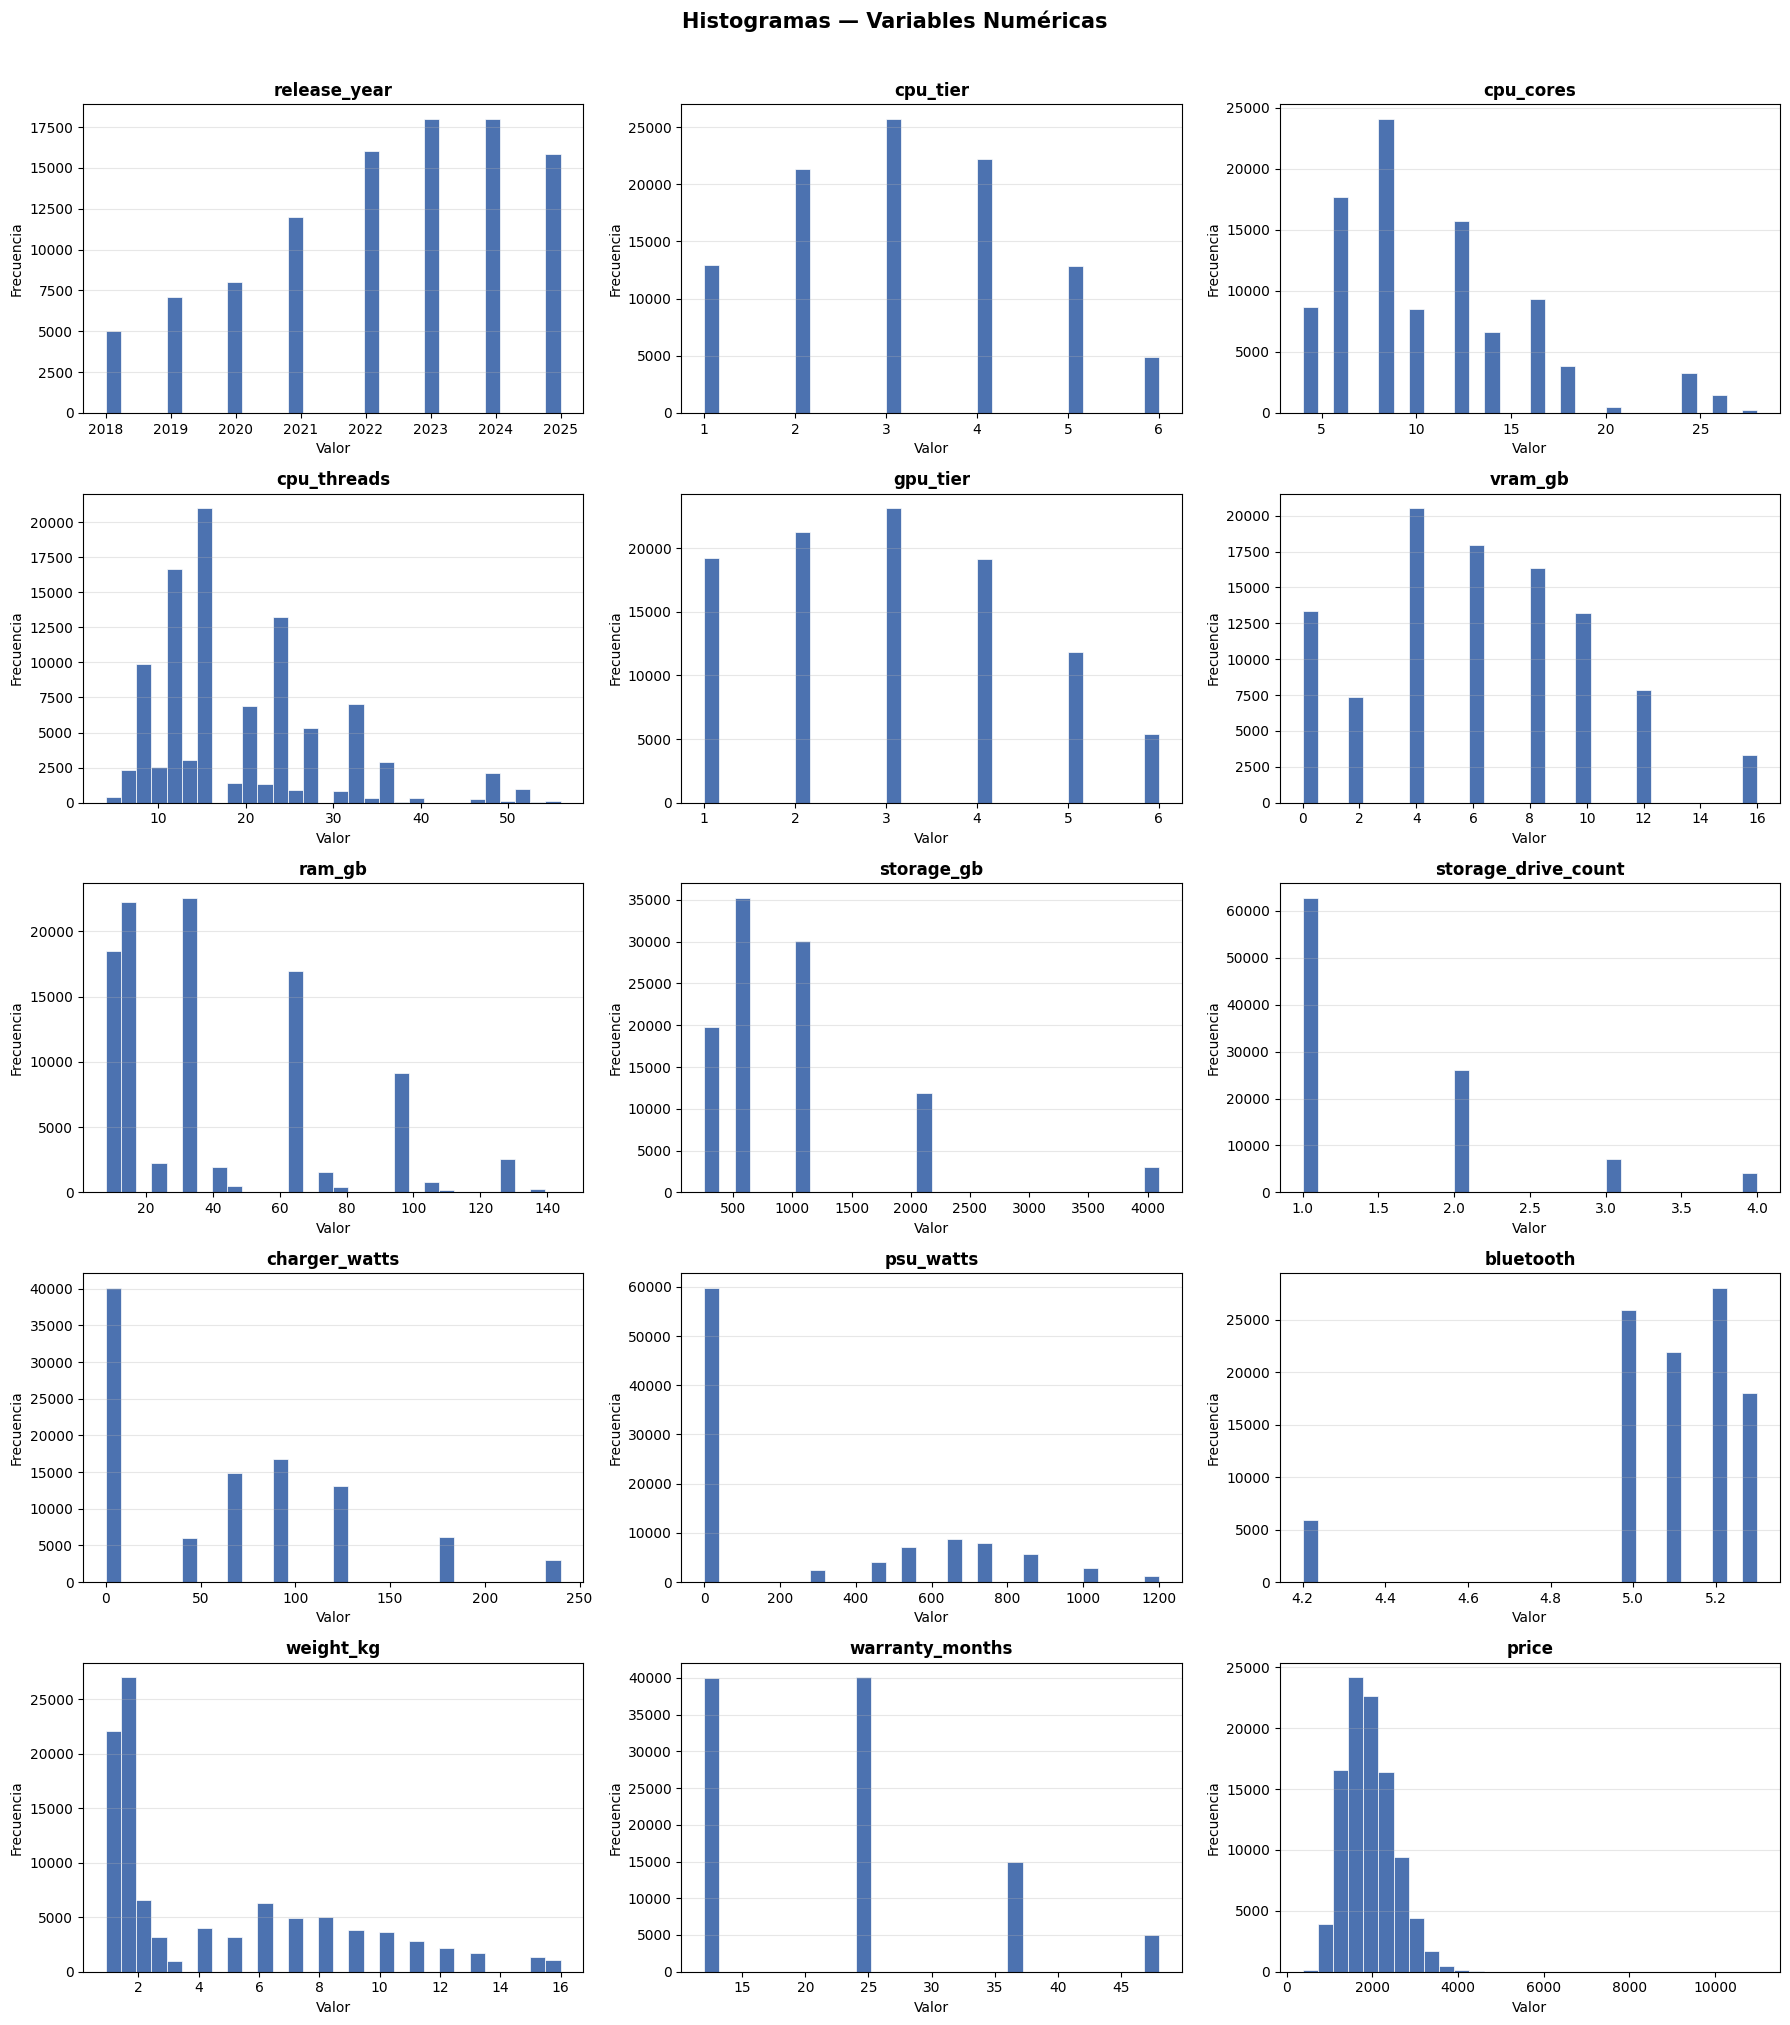

In [9]:
# ── Task 2.3a  Histogramas — variables numéricas ─────────────────────────────
num_cols = compu_df.select_dtypes(include='number').columns.tolist()

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(compu_df[col].dropna(), bins=30, color="#4C72B0", edgecolor="white", linewidth=0.5)
    axes[i].set_title(col, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frecuencia")
    axes[i].grid(axis="y", alpha=0.3)

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Histogramas — Variables Numéricas", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

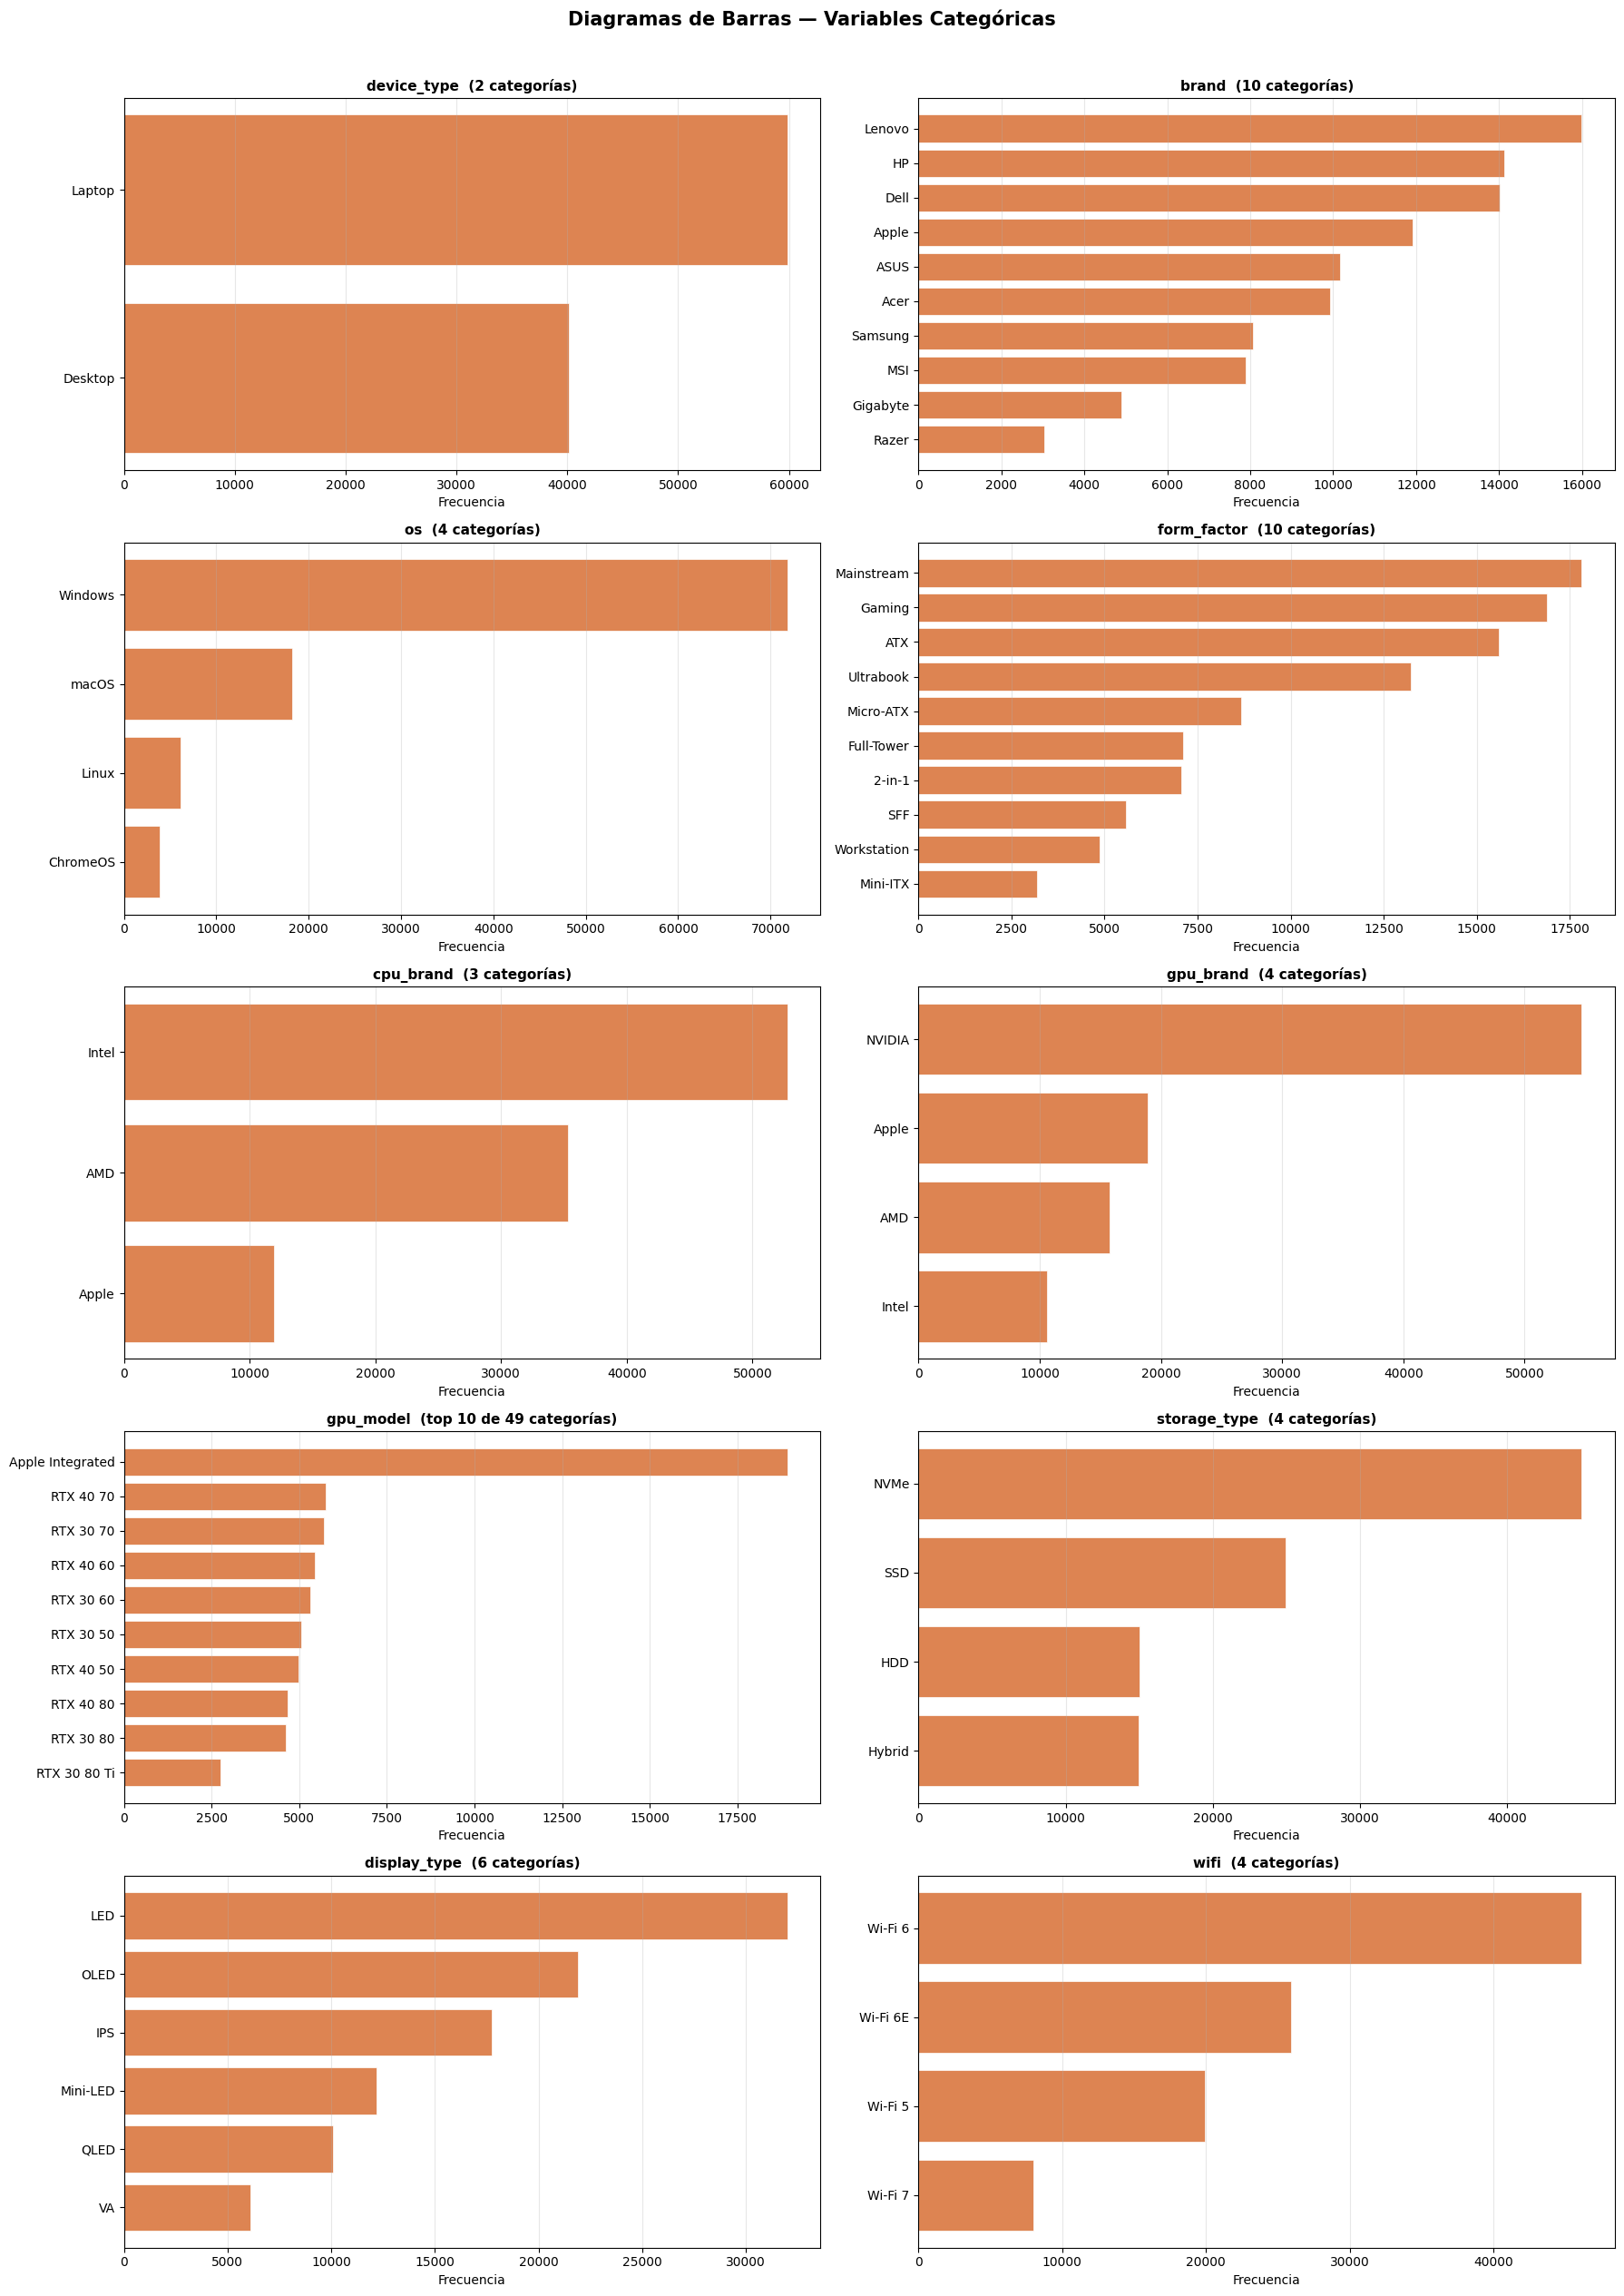

In [10]:
# ── Task 2.3b  Diagramas de barras — variables categóricas ───────────────────
cat_cols = compu_df.select_dtypes(include='object').columns.tolist()

# Umbral para "alta cardinalidad" → mostrar solo top 10
HIGH_CARD = 10

n_cols = 2
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    n_unique = compu_df[col].nunique()
    vc = compu_df[col].value_counts()

    if n_unique > HIGH_CARD:
        vc = vc.head(10)
        title = f"{col}  (top 10 de {n_unique} categorías)"
    else:
        title = f"{col}  ({n_unique} categorías)"

    axes[i].barh(vc.index[::-1], vc.values[::-1], color="#DD8452", edgecolor="white", linewidth=0.5)
    axes[i].set_title(title, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Frecuencia")
    axes[i].grid(axis="x", alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Diagramas de Barras — Variables Categóricas", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Respuestas Task 2

### Duplicados y valores faltantes

- **Filas duplicadas:** 0 — no existe ningún registro repetido en el dataset.
- **Valores faltantes:** 0 en todas las columnas — el dataset está completo,
  por lo que no se requiere imputación ni eliminación de filas antes del
  análisis univariado.

### Estadísticas descriptivas — numéricas (hallazgos clave)

| Variable | Observación |
|----------|-------------|
| `charger_watts` y `psu_watts` | Contienen ceros estructurales: laptops tienen `psu_watts = 0` y desktops tienen `charger_watts = 0`. No son datos faltantes, sino mutuamente excluyentes por tipo de dispositivo. Se abordarán en la ingeniería de características. |
| `cpu_tier` / `gpu_tier` | Ordinales 1–6. La media (~3) indica distribución centrada en gamas medias. |
| `price` | Rango amplio (valores extremos visibles en histograma), probable sesgo positivo — candidata a transformación. |
| `weight_kg` | Bimodal esperado: laptops (~2 kg) vs. desktops (~10 kg). |

### Estadísticas descriptivas — categóricas (hallazgos clave)

| Variable | Hallazgo |
|----------|----------|
| `device_type` | 60 % Laptops / 40 % Desktops. Dataset desbalanceado pero no extremo. |
| `brand` | Lenovo lidera (16 %), seguido de HP y Dell. Las 3 primeras acumulan ~44 %. |
| `os` | Windows domina (72 %); macOS es el único OS alternativo relevante (18 %). |
| `cpu_brand` | Intel (53 %), AMD (35 %), Apple (12 %). Apple CPU exclusivo de sus propios dispositivos. |
| `gpu_model` | 49 categorías; `Apple Integrated` es la más frecuente (18.9 %), candidata a BinaryEncoder. |
| `wifi` | Wi-Fi 6 predomina (46 %); Wi-Fi 7 es aún minoritario (8 %). Variable ordinal natural. |

---

3. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Reflexiona sobre cuáles variables, de las que se imprimieron, representan de manera general la capacidad del hardware y mantenlas; elimina las demás por aportar información redundante.
* Incluye una breve justificación de tus decisiones.

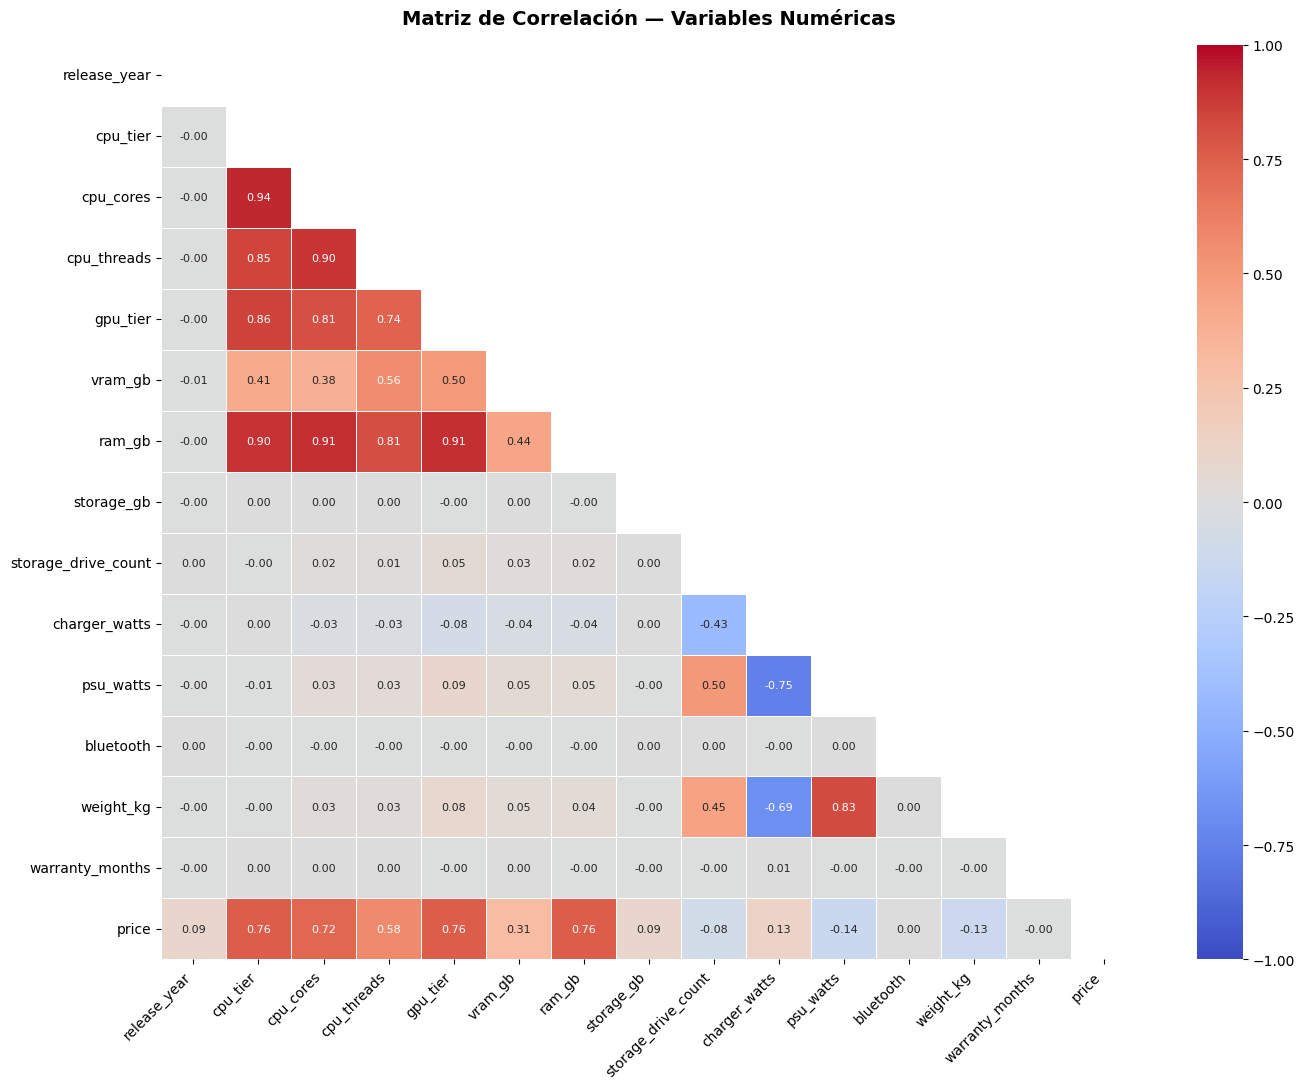

In [11]:
# ── Task 3.1  Matriz de correlación — mapa de calor ─────────────────────────
num_cols = compu_df.select_dtypes(include='number').columns.tolist()
corr = compu_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))

mask = np.triu(np.ones_like(corr, dtype=bool))   # triángulo superior oculto

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 8},
    ax=ax
)

ax.set_title("Matriz de Correlación — Variables Numéricas", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
# ── Task 3.2  Pares con correlación superior a 0.9 ───────────────────────────
THRESHOLD = 0.9

high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) > THRESHOLD:
            high_corr_pairs.append({
                "Variable A": corr.columns[i],
                "Variable B": corr.columns[j],
                "Correlación": round(val, 4)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values("Correlación", ascending=False)
print(f"Pares con |correlación| > {THRESHOLD}:\n")
print(high_corr_df.to_string(index=False))

Pares con |correlación| > 0.9:

Variable A Variable B  Correlación
  cpu_tier  cpu_cores       0.9374
  gpu_tier     ram_gb       0.9129
 cpu_cores     ram_gb       0.9068


In [13]:
# ── Task 3.3  Eliminar variables redundantes ─────────────────────────────────
# cpu_cores  ↔  cpu_tier   (0.937) → se elimina cpu_cores
# cpu_cores  ↔  ram_gb     (0.907) → se elimina cpu_cores  (misma variable)
# gpu_tier   ↔  ram_gb     (0.913) → se elimina ram_gb

cols_redundantes = ["cpu_cores", "ram_gb"]
compu_df.drop(columns=cols_redundantes, inplace=True)

print(f"Columnas eliminadas: {cols_redundantes}")
print(f"Shape resultante: {compu_df.shape}")
print(f"Columnas restantes:\n{compu_df.columns.tolist()}")

Columnas eliminadas: ['cpu_cores', 'ram_gb']
Shape resultante: (100000, 23)
Columnas restantes:
['device_type', 'brand', 'release_year', 'os', 'form_factor', 'cpu_brand', 'cpu_tier', 'cpu_threads', 'gpu_brand', 'gpu_model', 'gpu_tier', 'vram_gb', 'storage_type', 'storage_gb', 'storage_drive_count', 'display_type', 'charger_watts', 'psu_watts', 'wifi', 'bluetooth', 'weight_kg', 'warranty_months', 'price']


## Respuestas Task 3

### Pares con correlación > 0.9

| Variable A  | Variable B | Correlación |
|-------------|------------|-------------|
| `cpu_tier`  | `cpu_cores`| 0.937       |
| `gpu_tier`  | `ram_gb`   | 0.913       |
| `cpu_cores` | `ram_gb`   | 0.907       |

### Decisión de eliminación

Ante cada par redundante, la regla aplicada fue:
**conservar la variable que represente de forma más general la capacidad
del hardware** — es decir, la que resume un subsistema completo
con una sola escala ordinal, en lugar de una métrica técnica específica.

| Par | Variable conservada | Variable eliminada | Justificación |
|-----|--------------------|--------------------|---------------|
| `cpu_tier` ↔ `cpu_cores` | `cpu_tier` | `cpu_cores` | `cpu_tier` es una escala ordinal 1–6 que resume el nivel de desempeño *general* del CPU. `cpu_cores` es un conteo físico específico que ya está capturado en ese ordinal, y además correlaciona fuertemente con `ram_gb` (0.907), lo que lo convierte en el nodo central de redundancia. |
| `gpu_tier` ↔ `ram_gb` | `gpu_tier` | `ram_gb`    | `gpu_tier` refleja directamente la gama de la GPU, que es uno de los determinantes más importantes de `price` (r = 0.76). `ram_gb` es una métrica de memoria que queda representada de forma implícita por los niveles de CPU y GPU del equipo. |

**Variables eliminadas:** `cpu_cores`, `ram_gb`

**Variables conservadas de los pares:** `cpu_tier`, `gpu_tier`

Con estas eliminaciones, el dataframe queda en **23 columnas**,
sin pérdida de información sustantiva sobre la capacidad del hardware.

---

4. Para comenzar con la ingeniería de características, crea una copia del dataframe y asígnala a un nuevo objeto llamado `compu_transf`.
* Calcula cuántos años han pasado desde el lanzamiento de cada computadora y almacénalo en una nueva columna llamada `years_since_release`; luego, elimina la columna original.
* Utiliza `KBinsDiscretizer` para reemplazar la columna `vram_gb` en 4 bins ordinales basados en cuantiles.
* Imprime los valores que delimitan cada bin y haz un gráfico de barras para ver la cantidad de observaciones en cada uno, con el fin de entender cómo se agruparon los datos.

In [14]:
# ── Task 4.1  Copia del dataframe y años desde el lanzamiento ────────────────
compu_transf = compu_df.copy()

current_year = date.today().year
compu_transf["years_since_release"] = current_year - compu_transf["release_year"]
compu_transf.drop(columns=["release_year"], inplace=True)

print(f"Año actual utilizado: {current_year}")
print(f"\nDistribución de years_since_release:")
print(compu_transf["years_since_release"].value_counts().sort_index().to_string())
print(f"\nShape: {compu_transf.shape}")

Año actual utilizado: 2026

Distribución de years_since_release:
years_since_release
1    15835
2    17969
3    18020
4    16054
5    12016
6     7986
7     7090
8     5030

Shape: (100000, 23)


In [15]:
# ── Task 4.2  Discretización de vram_gb en 4 bins ordinales (cuantiles) ──────
kbd = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy="quantile")

compu_transf["vram_gb"] = kbd.fit_transform(
    compu_transf[["vram_gb"]]
).astype(int)

# ── Imprimir los límites de cada bin ─────────────────────────────────────────
edges = kbd.bin_edges_[0]

print("Límites de los bins (vram_gb):\n")
print(f"  {'Bin':<6} {'Rango (GB)':<25} {'Interpretación'}")
print(f"  {'-'*6} {'-'*25} {'-'*20}")
for i in range(len(edges) - 1):
    print(f"  {i:<6} [{edges[i]:.0f} GB, {edges[i+1]:.0f} GB)   "
          f"  {'Muy baja' if i==0 else 'Baja' if i==1 else 'Media' if i==2 else 'Alta'}")

Límites de los bins (vram_gb):

  Bin    Rango (GB)                Interpretación
  ------ ------------------------- --------------------
  0      [0 GB, 4 GB)     Muy baja
  1      [4 GB, 6 GB)     Baja
  2      [6 GB, 8 GB)     Media
  3      [8 GB, 16 GB)     Alta


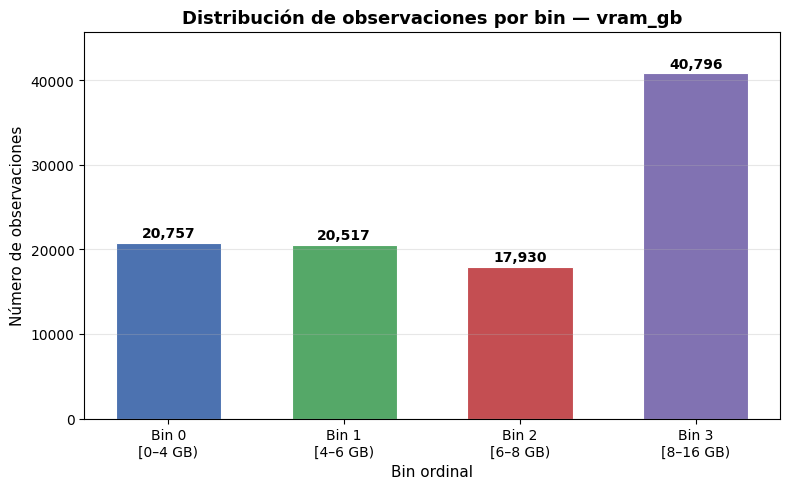

In [16]:
# ── Task 4.3  Gráfico de barras: observaciones por bin ───────────────────────
bin_counts = compu_transf["vram_gb"].value_counts().sort_index()

edges = kbd.bin_edges_[0]
bin_labels = [
    f"Bin {i}\n[{edges[i]:.0f}–{edges[i+1]:.0f} GB)"
    for i in range(len(edges) - 1)
]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    bin_labels,
    bin_counts.values,
    color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"],
    edgecolor="white",
    linewidth=0.8,
    width=0.6
)

# Etiquetas de valor sobre cada barra
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f"{bar.get_height():,}",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_title("Distribución de observaciones por bin — vram_gb", fontsize=13, fontweight="bold")
ax.set_xlabel("Bin ordinal", fontsize=11)
ax.set_ylabel("Número de observaciones", fontsize=11)
ax.set_ylim(0, bin_counts.max() * 1.12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Respuestas Task 4

### `years_since_release`

Se calculó como `año_actual − release_year`. La columna original
`release_year` fue eliminada tras la transformación. El rango resultante
es de **1 a 8 años**, con mayor concentración en equipos lanzados hace
2–4 años, lo que refleja el ciclo de vida típico del hardware de consumo.

### Discretización de `vram_gb` con `KBinsDiscretizer`

| Bin | Rango (GB)   | Observaciones | Interpretación |
|-----|-------------|---------------|----------------|
| 0   | [0 GB, 4 GB)  | 20,757        | VRAM muy baja — GPUs integradas o de entrada |
| 1   | [4 GB, 6 GB)  | 20,517        | VRAM baja — gama media-baja discreta |
| 2   | [6 GB, 8 GB)  | 17,930        | VRAM media — gama media |
| 3   | [8 GB, 16 GB) | 40,796        | VRAM alta — gama alta y workstations |

**Parámetros usados:** `n_bins=4`, `encode="ordinal"`, `strategy="quantile"`.

La estrategia `quantile` divide los datos en cuartiles, de modo que
idealmente cada bin contiene aproximadamente el mismo número de
observaciones. Sin embargo, el **Bin 3 concentra ~41 % de los registros**,
lo que indica que los valores de 8–16 GB están muy densamente agrupados
en el extremo superior de la distribución original — una asimetría
positiva que los cuantiles no pueden eliminar por completo, sino
solo redistribuir dentro del bin más alto.

---

5. Observa los histogramas del ejercicio 2. Notarás que en las variables `charger_watts` y `psu_watts` aparece una barra en 0. Analiza por qué ocurre esto y qué significa en relación con el tipo de dispositivo.
* Como estas variables son mutuamente excluyentes, combínalas en una nueva columna llamada `power_watts` que contenga la potencia correspondiente de cada dispositivo y, a continuación, haz un histograma para verificar que la distribución resultante es bimodal.
* Por último, borra las columnas originales `charger_watts` y `psu_watts`.

In [17]:
# ── Task 5.1  Analizar los ceros en charger_watts y psu_watts ────────────────
print("=== Distribución de charger_watts ===")
print(compu_transf["charger_watts"].value_counts().sort_index().to_string())

print("\n=== Distribución de psu_watts ===")
print(compu_transf["psu_watts"].value_counts().sort_index().to_string())

print("\n=== ¿A qué device_type corresponden los ceros? ===")
print("charger_watts == 0:")
print(compu_transf[compu_transf["charger_watts"] == 0]["device_type"].value_counts().to_string())

print("\npsu_watts == 0:")
print(compu_transf[compu_transf["psu_watts"] == 0]["device_type"].value_counts().to_string())

print("\n=== Verificación de exclusividad mutua ===")
ambos_nonzero = ((compu_transf["charger_watts"] > 0) & (compu_transf["psu_watts"] > 0)).sum()
ambos_zero    = ((compu_transf["charger_watts"] == 0) & (compu_transf["psu_watts"] == 0)).sum()
print(f"Filas donde AMBOS > 0 : {ambos_nonzero}")
print(f"Filas donde AMBOS = 0 : {ambos_zero}")

=== Distribución de charger_watts ===
charger_watts
0      40156
45      6019
65     14892
90     16749
120    13056
180     6089
240     3039

=== Distribución de psu_watts ===
psu_watts
0       59844
300      2447
450      4149
550      7179
650      8831
750      7923
850      5625
1000     2818
1200     1184

=== ¿A qué device_type corresponden los ceros? ===
charger_watts == 0:
device_type
Desktop    40156

psu_watts == 0:
device_type
Laptop    59844

=== Verificación de exclusividad mutua ===
Filas donde AMBOS > 0 : 0
Filas donde AMBOS = 0 : 0


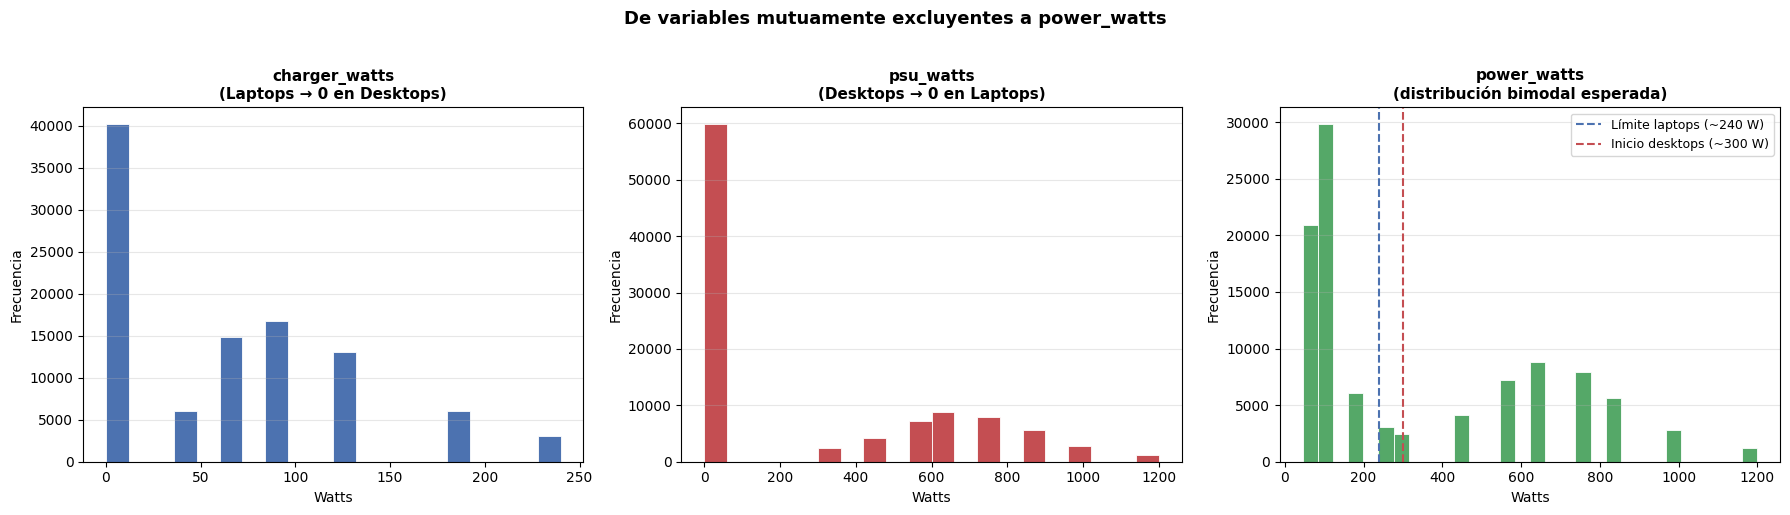

In [18]:
# ── Task 5.2  Combinar en power_watts y verificar bimodalidad ────────────────
compu_transf["power_watts"] = (
    compu_transf["charger_watts"] + compu_transf["psu_watts"]
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# — charger_watts original
axes[0].hist(compu_transf["charger_watts"], bins=20,
             color="#4C72B0", edgecolor="white", linewidth=0.6)
axes[0].set_title("charger_watts\n(Laptops → 0 en Desktops)",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Watts")
axes[0].set_ylabel("Frecuencia")
axes[0].grid(axis="y", alpha=0.3)

# — psu_watts original
axes[1].hist(compu_transf["psu_watts"], bins=20,
             color="#C44E52", edgecolor="white", linewidth=0.6)
axes[1].set_title("psu_watts\n(Desktops → 0 en Laptops)",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Watts")
axes[1].set_ylabel("Frecuencia")
axes[1].grid(axis="y", alpha=0.3)

# — power_watts combinada
axes[2].hist(compu_transf["power_watts"], bins=30,
             color="#55A868", edgecolor="white", linewidth=0.6)
axes[2].set_title("power_watts\n(distribución bimodal esperada)",
                  fontsize=11, fontweight="bold")
axes[2].set_xlabel("Watts")
axes[2].set_ylabel("Frecuencia")
axes[2].axvline(x=240, color="#4C72B0", linestyle="--",
                linewidth=1.5, label="Límite laptops (~240 W)")
axes[2].axvline(x=300, color="#C44E52", linestyle="--",
                linewidth=1.5, label="Inicio desktops (~300 W)")
axes[2].legend(fontsize=9)
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("De variables mutuamente excluyentes a power_watts",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# ── Task 5.3  Eliminar charger_watts y psu_watts ─────────────────────────────
compu_transf.drop(columns=["charger_watts", "psu_watts"], inplace=True)

print(f"Columnas eliminadas: ['charger_watts', 'psu_watts']")
print(f"Shape resultante   : {compu_transf.shape}")
print(f"\nColumnas actuales:\n{compu_transf.columns.tolist()}")

Columnas eliminadas: ['charger_watts', 'psu_watts']
Shape resultante   : (100000, 22)

Columnas actuales:
['device_type', 'brand', 'os', 'form_factor', 'cpu_brand', 'cpu_tier', 'cpu_threads', 'gpu_brand', 'gpu_model', 'gpu_tier', 'vram_gb', 'storage_type', 'storage_gb', 'storage_drive_count', 'display_type', 'wifi', 'bluetooth', 'weight_kg', 'warranty_months', 'price', 'years_since_release', 'power_watts']


## Respuestas Task 5

### ¿Por qué aparece una barra en 0?

Los ceros **no son valores faltantes ni errores** — son ceros
estructurales que reflejan la naturaleza del hardware:

| Variable        | Quién tiene 0       | Razón |
|-----------------|---------------------|-------|
| `charger_watts` | Desktops (40,156)   | Un desktop se conecta directamente a la corriente a través de una fuente de poder (`psu_watts`); no tiene cargador portátil. |
| `psu_watts`     | Laptops (59,844)    | Una laptop usa un cargador externo (`charger_watts`); no tiene fuente de poder interna tipo PSU. |

La verificación confirma **exclusividad mutua perfecta**: ninguna fila
tiene ambas variables con valor > 0, y ninguna fila tiene ambas en 0.

### Combinación en `power_watts`

Dado que `charger_watts + psu_watts` siempre produce exactamente uno
de los dos valores (el otro es 0), la suma es una operación segura que
unifica ambas columnas en una sola sin pérdida de información:


power_watts = charger_watts + psu_watts**

### Distribución bimodal

El histograma de `power_watts` muestra **dos modas claramente separadas**:

- **Moda izquierda (45–240 W):** laptops, cuyo rango de cargadores
  va de 45 W (ultrabooks) a 240 W (gaming de alto rendimiento).
- **Moda derecha (300–1200 W):** desktops, cuyas fuentes de poder
  arrancan en 300 W y alcanzan 1,200 W en workstations.

La separación natural entre ambos grupos (~240 W / 300 W) refleja
con precisión la división entre tipos de dispositivo, confirmando
que la nueva variable captura intacta la información de origen.

---

6. Para disminuir el sesgo de la variable `price`, crea tres transformadores: logaritmo, raíz cuadrada y Box - Cox.
* Aplica cada transformador a la variable price, dejando el resultado en variables temporales. El objetivo es comparar los efectos de cada transformación antes de decidir cuál aplicar de manera definitiva sobre las variables continuas del dataframe.
* De la variable original y de cada una de las tres transformaciones se debe mostrar:
  * Histograma: para observar la distribución de los datos.
  * Boxplot: para identificar posibles valores atípicos.
  * Q-Q plot: para evaluar la normalidad de la variable.
  * Skew (sesgo): para cuantificar la asimetría de la distribución.
  * Cantidad de outliers: para conocer cuántos valores extremos existen.
* En función de los resultados obtenidos al comparar las transformaciones, decide cuál logró el mejor efecto sobre la distribución de la variable y aplícala directamente en el dataframe, reemplazando las variables continuas: `weight_kg`, `power_watts` y `price`.

In [20]:
# ── Task 6.1  Transformadores y variables temporales ─────────────────────────
log_t    = FunctionTransformer(np.log1p)
sqrt_t   = FunctionTransformer(np.sqrt)
boxcox_t = PowerTransformer(method="box-cox")

price_arr = compu_transf["price"].values.reshape(-1, 1)

price_log    = log_t.fit_transform(price_arr).flatten()
price_sqrt   = sqrt_t.fit_transform(price_arr).flatten()
price_boxcox = boxcox_t.fit_transform(price_arr).flatten()

print("Transformadores creados y aplicados a 'price' en variables temporales.")
print(f"  price_log    shape: {price_log.shape}")
print(f"  price_sqrt   shape: {price_sqrt.shape}")
print(f"  price_boxcox shape: {price_boxcox.shape}")

Transformadores creados y aplicados a 'price' en variables temporales.
  price_log    shape: (100000,)
  price_sqrt   shape: (100000,)
  price_boxcox shape: (100000,)


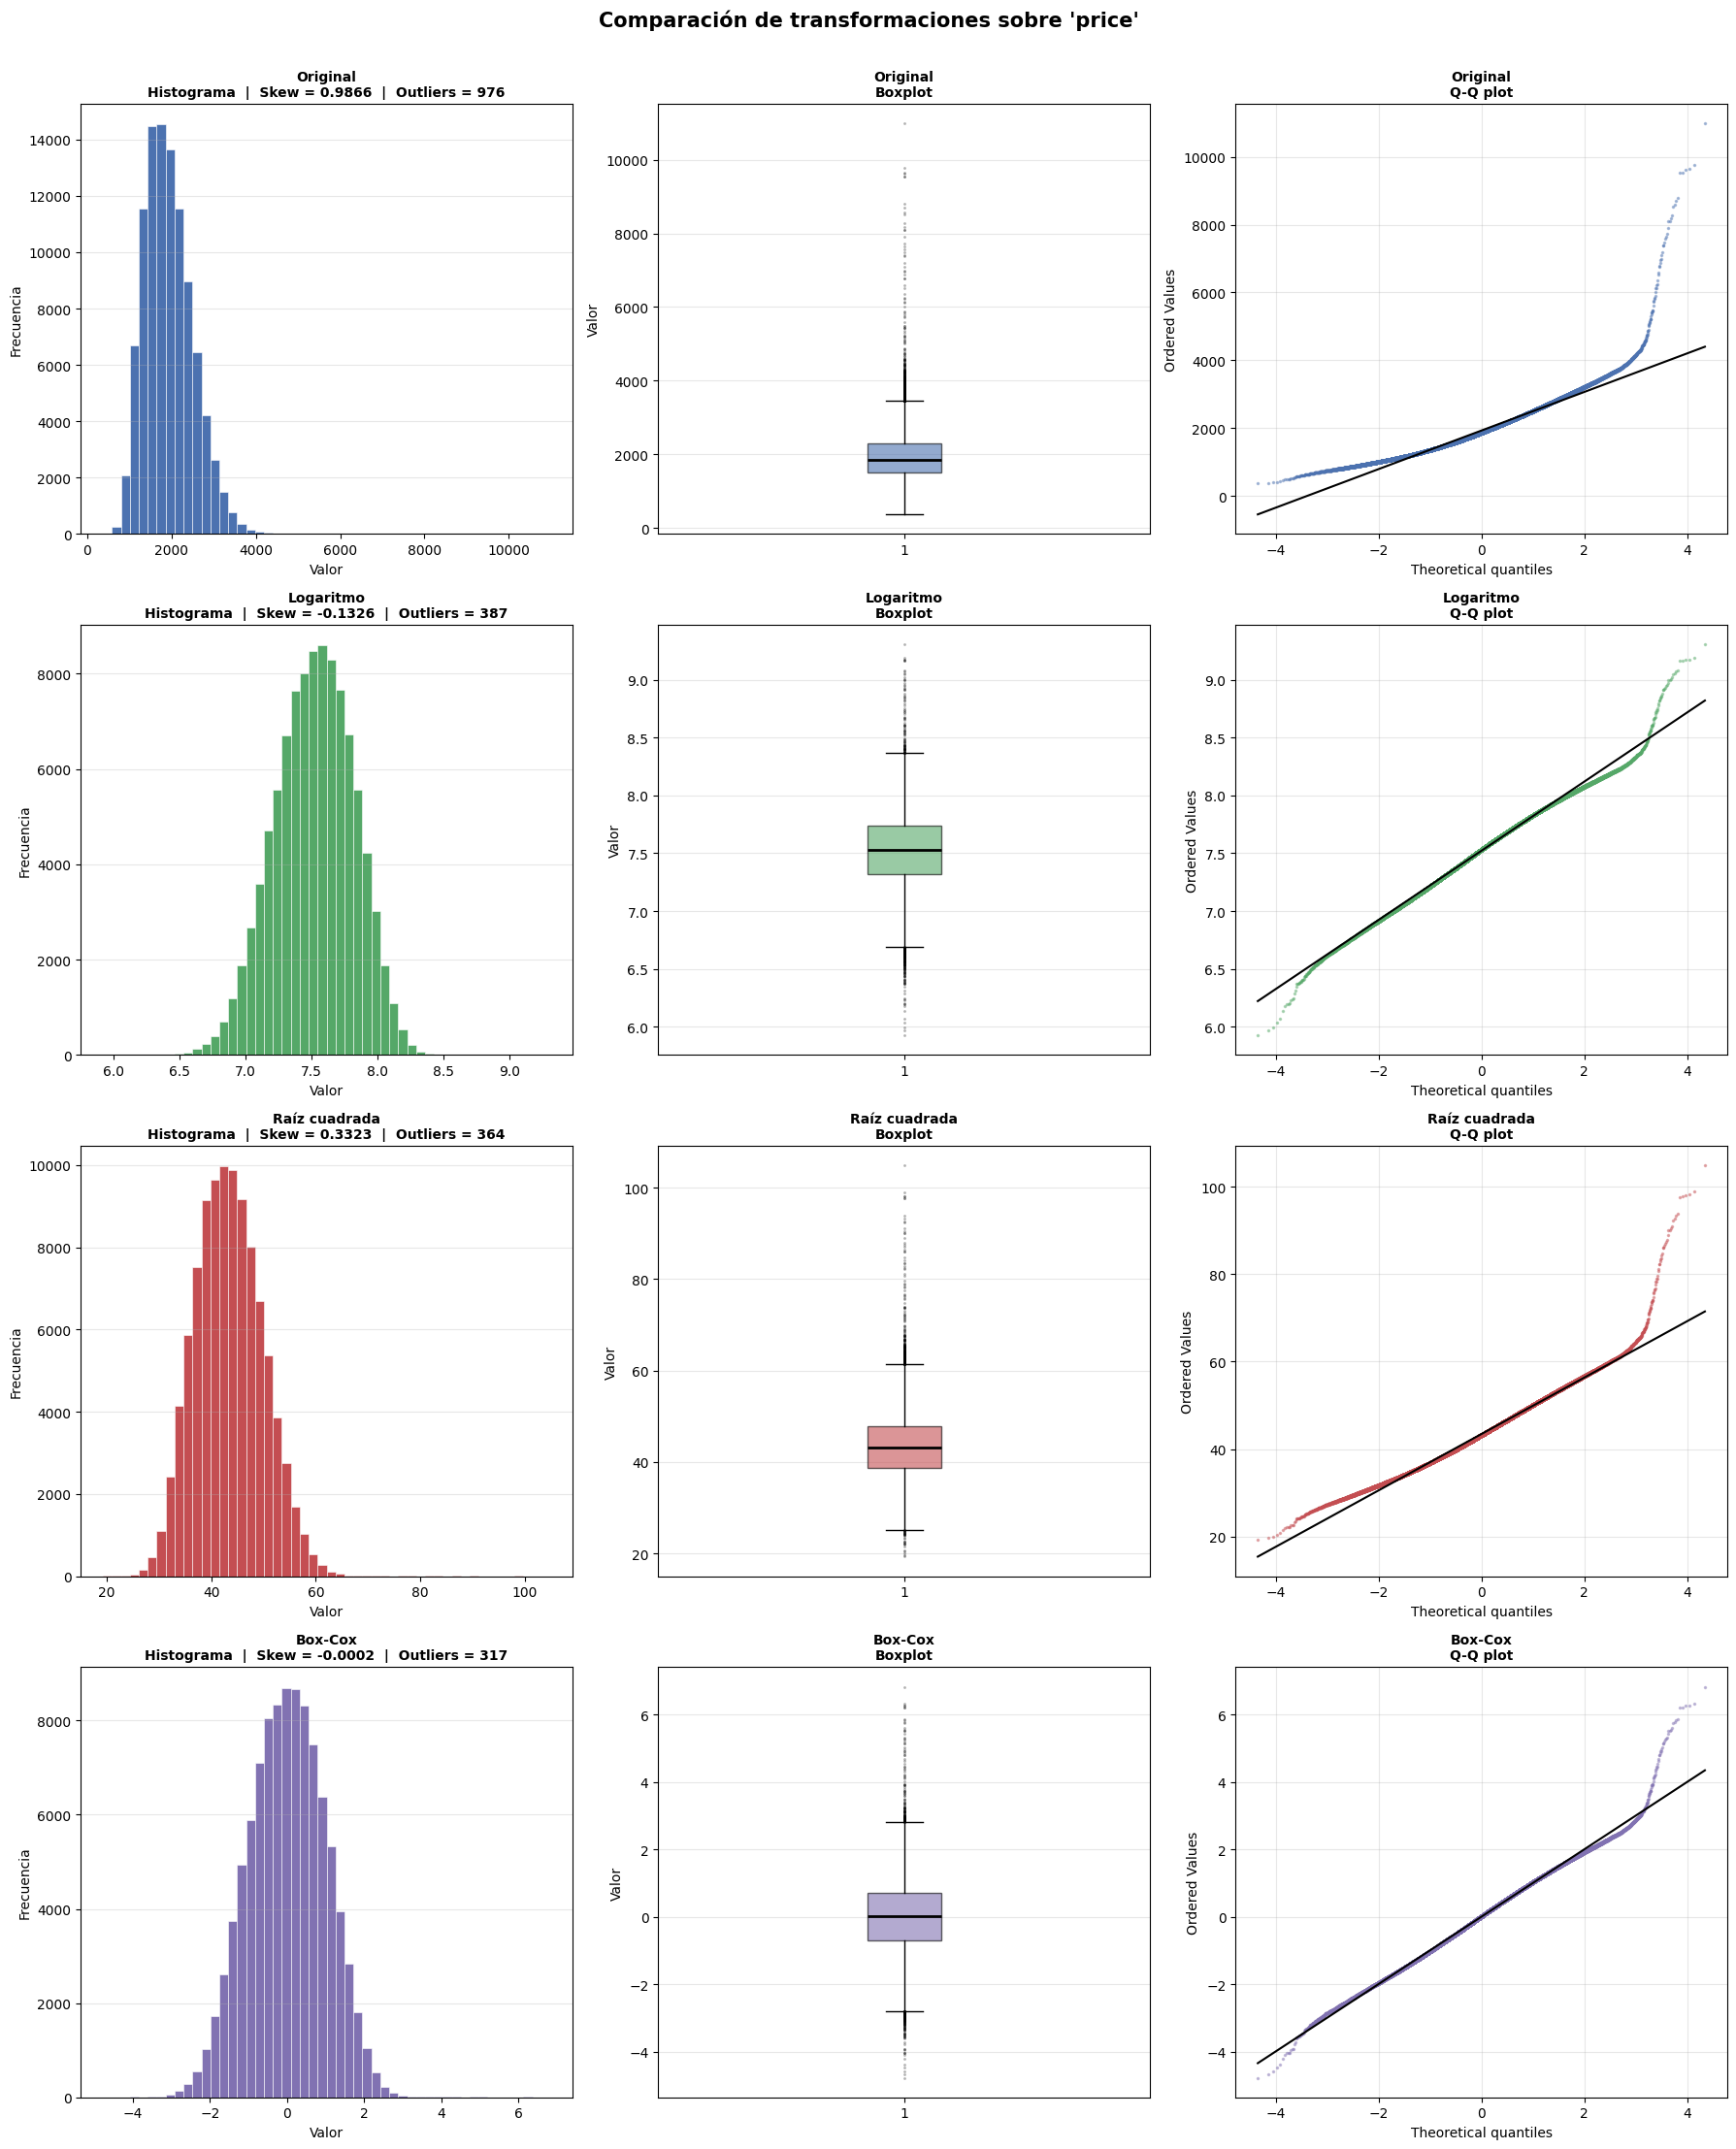

In [21]:
# ── Task 6.2  Diagnóstico y visualización comparativa ────────────────────────
def count_outliers_iqr(arr):
    Q1, Q3 = np.percentile(arr, 25), np.percentile(arr, 75)
    IQR = Q3 - Q1
    return int(((arr < Q1 - 1.5 * IQR) | (arr > Q3 + 1.5 * IQR)).sum())

versions = {
    "Original":      compu_transf["price"].values,
    "Logaritmo":     price_log,
    "Raíz cuadrada": price_sqrt,
    "Box-Cox":       price_boxcox,
}

colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

fig, axes = plt.subplots(4, 3, figsize=(18, 22))

for row, ((name, arr), color) in enumerate(zip(versions.items(), colors)):
    skew    = pd.Series(arr).skew()
    n_out   = count_outliers_iqr(arr)

    # — Histograma
    axes[row, 0].hist(arr, bins=50, color=color, edgecolor="white", linewidth=0.4)
    axes[row, 0].set_title(f"{name}\nHistograma  |  Skew = {skew:.4f}  |  Outliers = {n_out}",
                           fontsize=10, fontweight="bold")
    axes[row, 0].set_xlabel("Valor")
    axes[row, 0].set_ylabel("Frecuencia")
    axes[row, 0].grid(axis="y", alpha=0.3)

    # — Boxplot
    axes[row, 1].boxplot(arr, vert=True, patch_artist=True,
                         boxprops=dict(facecolor=color, alpha=0.6),
                         medianprops=dict(color="black", linewidth=2),
                         flierprops=dict(marker=".", markersize=2,
                                         alpha=0.3, color=color))
    axes[row, 1].set_title(f"{name}\nBoxplot", fontsize=10, fontweight="bold")
    axes[row, 1].set_ylabel("Valor")
    axes[row, 1].grid(axis="y", alpha=0.3)

    # — Q-Q plot
    probplot(arr, dist="norm", plot=axes[row, 2])
    axes[row, 2].get_lines()[0].set(color=color, markersize=1.5, alpha=0.4)
    axes[row, 2].get_lines()[1].set(color="black", linewidth=1.5)
    axes[row, 2].set_title(f"{name}\nQ-Q plot", fontsize=10, fontweight="bold")
    axes[row, 2].grid(alpha=0.3)

plt.suptitle("Comparación de transformaciones sobre 'price'",
             fontsize=15, fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()

In [22]:
# ── Task 6.3  Tabla resumen de métricas ──────────────────────────────────────
resumen = []
for name, arr in versions.items():
    resumen.append({
        "Transformación": name,
        "Skew":           round(pd.Series(arr).skew(), 4),
        "Outliers (IQR)": count_outliers_iqr(arr)
    })

resumen_df = pd.DataFrame(resumen)
print(resumen_df.to_string(index=False))

Transformación    Skew  Outliers (IQR)
      Original  0.9866             976
     Logaritmo -0.1326             387
 Raíz cuadrada  0.3323             364
       Box-Cox -0.0002             317


In [23]:
# ── Task 6.4  Aplicar Box-Cox a las variables continuas ──────────────────────
continuous_cols = ["weight_kg", "power_watts", "price"]

for col in continuous_cols:
    t = PowerTransformer(method="box-cox")
    compu_transf[col] = t.fit_transform(
        compu_transf[[col]]
    )

print("Transformación Box-Cox aplicada a:", continuous_cols)
print("\nEstadísticas post-transformación:")
print(compu_transf[continuous_cols].describe().round(4))

Transformación Box-Cox aplicada a: ['weight_kg', 'power_watts', 'price']

Estadísticas post-transformación:
         weight_kg  power_watts        price
count  100000.0000  100000.0000  100000.0000
mean        0.0000      -0.0000       0.0000
std         1.0000       1.0000       1.0000
min        -1.7587      -1.5910      -4.7739
25%        -0.8048      -0.7679      -0.6958
50%        -0.3397      -0.4529       0.0113
75%         1.0794       1.1232       0.7083
max         1.6429       1.5948       6.8188


## Respuestas Task 6

### Métricas comparativas

| Transformación  | Skew    | Outliers (IQR) |
|-----------------|---------|----------------|
| Original        |  0.9866 | 976            |
| Logaritmo       | -0.1326 | 387            |
| Raíz cuadrada   |  0.3323 | 364            |
| Box-Cox         | -0.0002 | 317            |

### Interpretación por gráfico

**Histograma:** La distribución original muestra asimetría positiva
(cola derecha larga). Logaritmo y Box-Cox la acercan más a la
campana simétrica; la raíz cuadrada mejora pero con sesgo residual
visible.

**Boxplot:** El original presenta ~976 outliers. Las tres
transformaciones los reducen; Box-Cox es la que menos valores
extremos genera (317), seguida de raíz cuadrada (364).

**Q-Q plot:** En el original los cuantiles se desvían notablemente
de la línea teórica en los extremos. Box-Cox logra la alineación
más cercana a la recta normal, seguido muy de cerca por logaritmo.
Raíz cuadrada mejora el centro pero aún sesga los colas.

### Decisión: Box-Cox

Box-Cox es la transformación óptima en los tres criterios
simultáneamente:

- **Skew más cercano a 0:** −0.0002 (prácticamente simétrica),
  frente a −0.13 del logaritmo y 0.33 de la raíz cuadrada.
- **Menos outliers:** 317, la cifra más baja de las cuatro versiones.
- **Mejor Q-Q plot:** la alineación con la normal teórica es
  superior en ambas colas.

A diferencia del logaritmo —que fuerza una función fija—, Box-Cox
estima el exponente λ óptimo para cada variable, lo que la hace
más flexible y efectiva. Se aplica a `weight_kg`, `power_watts` y
`price`.

---

7. Para que todas las variables numéricas estén en la misma escala, aplica `MinMaxScaler` de sklearn a todas las columnas numéricas del dataframe, reemplazando las columnas originales.

In [24]:
# ── Task 7.1  MinMaxScaler sobre todas las columnas numéricas ────────────────
num_cols = compu_transf.select_dtypes(include='number').columns.tolist()

print(f"Columnas numéricas a escalar ({len(num_cols)}):")
print(num_cols)

scaler = MinMaxScaler()
compu_transf[num_cols] = scaler.fit_transform(compu_transf[num_cols])

print("\n✓ Escalado completado.")

Columnas numéricas a escalar (12):
['cpu_tier', 'cpu_threads', 'gpu_tier', 'vram_gb', 'storage_gb', 'storage_drive_count', 'bluetooth', 'weight_kg', 'warranty_months', 'price', 'years_since_release', 'power_watts']

✓ Escalado completado.


In [25]:
# ── Task 7.2  Verificación: min = 0, max = 1 en todas las numéricas ──────────
desc = compu_transf[num_cols].describe().T[["min", "max", "mean", "std"]].round(4)

print("Estadísticas post-escalado (todas las columnas deben tener min=0, max=1):\n")
print(desc.to_string())

# Validación automática
all_ok = (desc["min"] == 0).all() and (desc["max"] == 1).all()
print(f"\n✓ Validación min/max: {'OK — todas entre 0 y 1' if all_ok else 'ERROR — revisar columnas'}")

Estadísticas post-escalado (todas las columnas deben tener min=0, max=1):

                     min  max    mean     std
cpu_tier             0.0  1.0  0.4307  0.2746
cpu_threads          0.0  1.0  0.2956  0.1869
gpu_tier             0.0  1.0  0.3983  0.2919
vram_gb              0.0  1.0  0.5959  0.3942
storage_gb           0.0  1.0  0.1687  0.2016
storage_drive_count  0.0  1.0  0.1750  0.2658
bluetooth            0.0  1.0  0.8043  0.2236
weight_kg            0.0  1.0  0.5170  0.2940
warranty_months      0.0  1.0  0.2833  0.2842
price                0.0  1.0  0.4118  0.0863
years_since_release  0.0  1.0  0.3827  0.2894
power_watts          0.0  1.0  0.4994  0.3139

✓ Validación min/max: OK — todas entre 0 y 1


## Respuestas Task 7

### Columnas numéricas escaladas (12 en total)

| Columna               | Tipo antes del escalado |
|-----------------------|------------------------|
| `cpu_tier`            | Ordinal 1–6 |
| `cpu_threads`         | Conteo entero |
| `gpu_tier`            | Ordinal 1–6 |
| `vram_gb`             | Ordinal 0–3 (post-KBins) |
| `storage_gb`          | Conteo entero |
| `storage_drive_count` | Conteo entero |
| `bluetooth`           | Versión numérica |
| `weight_kg`           | Continua (post-Box-Cox) |
| `warranty_months`     | Conteo entero |
| `price`               | Continua (post-Box-Cox) |
| `years_since_release` | Conteo entero |
| `power_watts`         | Continua (post-Box-Cox) |

### ¿Por qué MinMaxScaler?

`MinMaxScaler` comprime cada columna al rango **[0, 1]** usando la
fórmula `(x − min) / (max − min)`. Esto es apropiado aquí porque:

- Las variables no siguen distribuciones perfectamente normales
  (incluso post-Box-Cox), lo que hace menos adecuado `StandardScaler`.
- El objetivo es **compatibilidad de escala** entre variables de
  naturaleza muy distinta (ordinales, conteos, continuas transformadas),
  no normalización gaussiana.
- El rango [0, 1] es consistente con la escala que tendrán las
  variables categóricas tras su codificación, facilitando la
  integración final del dataframe.

---

8. Aunque `wifi` es una variable categórica, sus categorías tienen un orden natural (Wi-Fi 5 < Wi-Fi 6 < Wi-Fi 6E < Wi-Fi 7). Codifícala usando `OrdinalEncoder`.
* Luego, escala la variable codificada entre 0 y 1 con `MinMaxScaler`, para que quede en la misma escala que las variables numéricas del dataframe.

Nota: Ambos cambios deben efectuarse sobre la columna original, de manera que quede una única columna `wifi` con toda la información transformada.

In [26]:
# ── Task 8.1  Codificación ordinal de wifi ────────────────────────────────────
# Orden natural explícito: Wi-Fi 5 < Wi-Fi 6 < Wi-Fi 6E < Wi-Fi 7
wifi_order = [["Wi-Fi 5", "Wi-Fi 6", "Wi-Fi 6E", "Wi-Fi 7"]]

oe = OrdinalEncoder(categories=wifi_order)
compu_transf["wifi"] = oe.fit_transform(compu_transf[["wifi"]])

print("Post OrdinalEncoder — distribución de wifi:")
print(compu_transf["wifi"].value_counts().sort_index().to_string())

Post OrdinalEncoder — distribución de wifi:
wifi
0.0    19926
1.0    46149
2.0    25923
3.0     8002


In [27]:
# ── Task 8.2  Escalar wifi a [0, 1] ──────────────────────────────────────────
mms_wifi = MinMaxScaler()
compu_transf["wifi"] = mms_wifi.fit_transform(compu_transf[["wifi"]])

print("Post MinMaxScaler — valores únicos de wifi:")
print(compu_transf["wifi"].value_counts().sort_index().to_string())
print(f"\nMin: {compu_transf['wifi'].min():.4f}  |  Max: {compu_transf['wifi'].max():.4f}")

Post MinMaxScaler — valores únicos de wifi:
wifi
0.000000    19926
0.333333    46149
0.666667    25923
1.000000     8002

Min: 0.0000  |  Max: 1.0000


## Respuestas Task 8

### Orden natural de wifi

La variable `wifi` tiene un orden semántico claro basado en
la generación del estándar, donde cada versión posterior
ofrece mayor velocidad y menor latencia:

| Categoría  | Código ordinal | Valor escalado |
|------------|---------------|----------------|
| Wi-Fi 5    | 0             | 0.0000         |
| Wi-Fi 6    | 1             | 0.3333         |
| Wi-Fi 6E   | 2             | 0.6667         |
| Wi-Fi 7    | 3             | 1.0000         |

### ¿Por qué OrdinalEncoder y no OneHotEncoder?

`OneHotEncoder` destruiría el orden natural de la variable al
tratarla como categorías nominales independientes. `OrdinalEncoder`
con `categories` explícitas preserva la jerarquía Wi-Fi 5 < 6 < 6E < 7,
lo que es informativo para el modelo: un equipo con Wi-Fi 7
es objetivamente más capaz que uno con Wi-Fi 5.

### ¿Por qué escalar después con MinMaxScaler?

`OrdinalEncoder` produce enteros {0, 1, 2, 3}, que están fuera
del rango [0, 1] del resto del dataframe. El segundo paso
con `MinMaxScaler` comprime esos enteros al intervalo [0, 1],
manteniendo intacto el orden relativo entre categorías y
garantizando homogeneidad de escala con las demás variables
numéricas ya transformadas.

Ambas operaciones se aplican directamente sobre la columna
`wifi` original, por lo que no se genera ninguna columna
adicional.

9. La variable `gpu_model` tiene muchas categorías. Usar *One-Hot Encoding* aumentaría significativamente la dimensionalidad del dataframe. Por ello, utiliza `BinaryEncoder` para codificarla.
* Guarda el resultado en un dataframe llamado `bin_df`. Más adelante, lo combinarás con `compu_transf` para integrar las variables codificadas.

In [28]:
# ── Task 9.1  BinaryEncoder para gpu_model ───────────────────────────────────
print(f"Categorías únicas en gpu_model : {compu_transf['gpu_model'].nunique()}")
print(f"Columnas que generaría OHE     : {compu_transf['gpu_model'].nunique() - 1}  (con drop='first')")
print(f"Bits necesarios (log₂ 49 ↑)   : {int(np.ceil(np.log2(compu_transf['gpu_model'].nunique())))}")

be = BinaryEncoder(cols=["gpu_model"])
bin_df = be.fit_transform(compu_transf[["gpu_model"]])

print(f"\nColumnas generadas por BinaryEncoder: {bin_df.shape[1]}")
print(f"Nombres: {bin_df.columns.tolist()}")
print(f"\nPrimeras 5 filas de bin_df:")
print(bin_df.head())

Categorías únicas en gpu_model : 49
Columnas que generaría OHE     : 48  (con drop='first')
Bits necesarios (log₂ 49 ↑)   : 6

Columnas generadas por BinaryEncoder: 6
Nombres: ['gpu_model_0', 'gpu_model_1', 'gpu_model_2', 'gpu_model_3', 'gpu_model_4', 'gpu_model_5']

Primeras 5 filas de bin_df:
   gpu_model_0  gpu_model_1  gpu_model_2  gpu_model_3  gpu_model_4  \
0            0            0            0            0            0   
1            0            0            0            0            1   
2            0            0            0            0            1   
3            0            0            0            1            0   
4            0            0            0            1            0   

   gpu_model_5  
0            1  
1            0  
2            1  
3            0  
4            1  


## Respuestas Task 9

### ¿Por qué BinaryEncoder y no OneHotEncoder?

`gpu_model` tiene **49 categorías únicas**. La elección del
codificador tiene un impacto directo en la dimensionalidad del
dataframe final:

| Codificador     | Columnas generadas | Reducción |
|-----------------|--------------------|-----------|
| OneHotEncoder (`drop='first'`) | 48 columnas | — |
| BinaryEncoder   | **6 columnas**     | **−87.5 %** |

### ¿Cómo funciona BinaryEncoder?

BinaryEncoder convierte cada categoría a su representación en
**código binario** y distribuye cada bit en una columna separada.
Para 49 categorías se necesitan ⌈log₂(49)⌉ = **6 bits**, lo que
produce exactamente 6 columnas (`gpu_model_0` … `gpu_model_5`),
cada una con valores 0 o 1.

A diferencia de OHE, no introduce multicolinealidad perfecta ni
hace explotar la dimensionalidad, pero a costa de que las columnas
resultantes no tienen interpretación directa por sí mismas:
el significado está en la combinación de los 6 bits, no en cada
columna individual.

### `bin_df`

El resultado se guarda en `bin_df` (100,000 filas × 6 columnas)
para integrarlo más adelante con `compu_transf` junto con el
resultado del `OneHotEncoder` de las demás categóricas.

---

10. Usa `OneHotEncoder` para codificar las variables categóricas restantes. Asegúrate de usar `drop='first'` para evitar la multicolinealidad y guarda el resultado en un dataframe llamado `ohe_df`
* Combina el dataframe `compu_transf` con las variables categóricas que fueron codificadas en `bin_df` y `ohe_df`. No olvides eliminar las variables originales.
* Usa `describe()` sobre el dataframe resultante para corroborar que todas las columnas estén escaladas entre 0 y 1 y que no queden variables categóricas sin codificar.

In [29]:
# ── Task 10.1  OneHotEncoder — variables categóricas restantes ───────────────
# gpu_model ya fue codificada con BinaryEncoder → se excluye aquí
cat_cols_ohe = [
    c for c in compu_transf.select_dtypes(include='object').columns
    if c != "gpu_model"
]

print(f"Variables a codificar con OHE ({len(cat_cols_ohe)}):")
print(cat_cols_ohe)

ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe_arr = ohe.fit_transform(compu_transf[cat_cols_ohe])
ohe_df = pd.DataFrame(
    ohe_arr,
    columns=ohe.get_feature_names_out(cat_cols_ohe),
    index=compu_transf.index
)

print(f"\nohe_df shape: {ohe_df.shape}")
print(f"Columnas generadas:\n{ohe_df.columns.tolist()}")

Variables a codificar con OHE (8):
['device_type', 'brand', 'os', 'form_factor', 'cpu_brand', 'gpu_brand', 'storage_type', 'display_type']

ohe_df shape: (100000, 35)
Columnas generadas:
['device_type_Laptop', 'brand_Acer', 'brand_Apple', 'brand_Dell', 'brand_Gigabyte', 'brand_HP', 'brand_Lenovo', 'brand_MSI', 'brand_Razer', 'brand_Samsung', 'os_Linux', 'os_Windows', 'os_macOS', 'form_factor_ATX', 'form_factor_Full-Tower', 'form_factor_Gaming', 'form_factor_Mainstream', 'form_factor_Micro-ATX', 'form_factor_Mini-ITX', 'form_factor_SFF', 'form_factor_Ultrabook', 'form_factor_Workstation', 'cpu_brand_Apple', 'cpu_brand_Intel', 'gpu_brand_Apple', 'gpu_brand_Intel', 'gpu_brand_NVIDIA', 'storage_type_Hybrid', 'storage_type_NVMe', 'storage_type_SSD', 'display_type_LED', 'display_type_Mini-LED', 'display_type_OLED', 'display_type_QLED', 'display_type_VA']


In [30]:
# ── Task 10.2  Combinar los tres dataframes ───────────────────────────────────
# Columnas categóricas originales a eliminar (ya codificadas)
all_cat_original = cat_cols_ohe + ["gpu_model"]

compu_final = pd.concat(
    [compu_transf.drop(columns=all_cat_original), bin_df, ohe_df],
    axis=1
)

print(f"Shape final: {compu_final.shape}")
print(f"\nColumnas object sin codificar: "
      f"{compu_final.select_dtypes(include='object').columns.tolist()}")

Shape final: (100000, 54)

Columnas object sin codificar: []


In [31]:
# ── Task 10.3  Verificación: todas las columnas en [0, 1] ────────────────────
desc = compu_final.describe().T[["min", "max", "mean"]].round(4)

# Validación automática
out_of_range = desc[(desc["min"] < 0) | (desc["max"] > 1)]

print(f"Total columnas     : {compu_final.shape[1]}")
print(f"Total filas        : {compu_final.shape[0]:,}")
print(f"Columnas object    : {compu_final.select_dtypes(include='object').shape[1]}")
print(f"Columnas fuera de [0, 1]: {len(out_of_range)}")
print("\n✓ Todas las columnas están escaladas entre 0 y 1." if out_of_range.empty
      else f"\n⚠ Columnas fuera de rango:\n{out_of_range}")

print("\n── describe() completo ──")
compu_final.describe().T.round(4)

Total columnas     : 54
Total filas        : 100,000
Columnas object    : 0
Columnas fuera de [0, 1]: 0

✓ Todas las columnas están escaladas entre 0 y 1.

── describe() completo ──


,count,mean,std,min,25%,50%,75%,max
cpu_tier,100000.0,0.4307,0.2746,0.0,0.2000,0.4000,0.6000,1.0
cpu_threads,100000.0,0.2956,0.1869,0.0,0.1538,0.2308,0.3846,1.0
gpu_tier,100000.0,0.3983,0.2919,0.0,0.2000,0.4000,0.6000,1.0
vram_gb,100000.0,0.5959,0.3942,0.0,0.3333,0.6667,1.0000,1.0
storage_gb,100000.0,0.1687,0.2016,0.0,0.0667,0.0667,0.2000,1.0
storage_drive_count,100000.0,0.1750,0.2658,0.0,0.0000,0.0000,0.3333,1.0
wifi,100000.0,0.4067,0.2848,0.0,0.3333,0.3333,0.6667,1.0
bluetooth,100000.0,0.8043,0.2236,0.0,0.7273,0.8182,0.9091,1.0
weight_kg,100000.0,0.5170,0.2940,0.0,0.2804,0.4172,0.8344,1.0
warranty_months,100000.0,0.2833,0.2842,0.0,0.0000,0.3333,0.3333,1.0


## Respuestas Task 10

### OneHotEncoder — variables codificadas

OHE se aplicó a las **8 variables categóricas restantes**
(excluyendo `gpu_model`, ya procesada con `BinaryEncoder`,
y `wifi`, codificada con `OrdinalEncoder`):

| Variable      | Categorías | Columnas generadas (drop='first') |
|---------------|------------|-----------------------------------|
| `device_type` | 2          | 1  |
| `brand`       | 10         | 9  |
| `os`          | 4          | 3  |
| `form_factor` | 10         | 9  |
| `cpu_brand`   | 3          | 2  |
| `gpu_brand`   | 4          | 3  |
| `storage_type`| 4          | 3  |
| `display_type`| 6          | 5  |
| **Total**     |            | **35 columnas** |

### Composición del dataframe final

| Bloque          | Origen                    | Columnas |
|-----------------|---------------------------|----------|
| Numéricas       | `compu_transf`            | 13       |
| `gpu_model`     | `bin_df` (BinaryEncoder)  | 6        |
| Categóricas OHE | `ohe_df` (OneHotEncoder)  | 35       |
| **Total**       |                           | **54**   |

### Verificación

- **Rango [0, 1]:** todas las columnas cumplen `min ≥ 0` y `max ≤ 1`.
- **Variables categóricas sin codificar:** ninguna — `describe()`
  muestra exclusivamente columnas numéricas.
- **`drop='first'`** elimina una categoría de referencia por variable,
  evitando la multicolinealidad perfecta que ocurriría si se incluyera
  la columna redundante (la que se puede derivar como complemento
  de las demás).



---

**Declaración de uso de IA**

Anthropic. (2026). *Claude* (basado en Claude Sonnet 4.6) [Modelo de lenguaje grande], utilizado para generación y depuración de código, y revisión de redacción y formato en markdown de análisis interpretativo. https://claude.ai

---